# Лабораторная работа #4
#### Дисциплина: _"Методы Оптимизации"_ ####


#### Выполнили: __Сафин Максим Владиславович__ (P3222) | __Фокин Владимир Сергеевич__ (P3223) ####

### Исходные данные  ####
Исследуемая функция: $ f(x) = 2x^2_1 + 2x_1x_2 + 3x^2_2 - 10x_1 - 10x_2 + 15 $;

Промежуток: $ [-2, 2] $


### Определим реализацию нашей функции. Построим ее графическое представление ###

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def f(_x1, _x2):
    """
    Квадратичная функция: f(x1, x2) = 2x1^2 + 2x1x2 + 3x2^2 - 10x1 - 10x2 + 15

    Параметры:
    x1, x2 : float или array-like
        Входные переменные

    Возвращает:
    float или array-like
        Значение функции
    """
    return 2*_x1**2 + 2*_x1*_x2 + 3*_x2**2 - 10*_x1 - 10*_x2 + 15

f(0, 0) = 15
f(1, 1) = 2
f(2, 2) = 3
f_vector([1, 1]) = 2


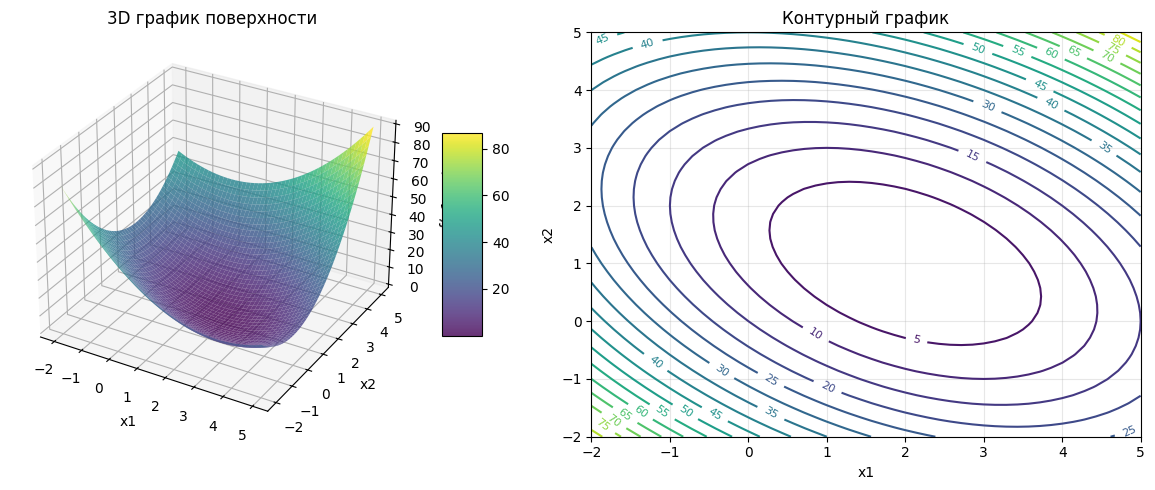

In [11]:
# Визуализация функции
x1_vals = np.linspace(-2, 5, 50)
x2_vals = np.linspace(-2, 5, 50)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2)

fig = plt.figure(figsize=(12, 5))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D график поверхности')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Контурный график')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Нахождение экстремумов аналитическим способом ###

Для функции двух переменных $f(x_1, x_2)$ экстремумы находятся через:

1. #### Необходимое условие экстремума

    В точке экстремума функции двух переменных все её частные производные первого порядка равны нулю:

    $$\begin{cases}
    \frac{\partial f}{\partial x_1} = 0 \\[10pt]
    \frac{\partial f}{\partial x_2} = 0
    \end{cases}$$

    Точки, удовлетворяющие этой системе, называются **стационарными**. В этих точках возможен экстремум, но не обязательно.

2. #### Достаточное условие экстремума

    Для определения типа стационарной точки вычисляются вторые частные производные:

    $$A = \frac{\partial^2 f}{\partial x_1^2}, \quad
    B = \frac{\partial^2 f}{\partial x_1 \partial x_2}, \quad
    C = \frac{\partial^2 f}{\partial x_2^2}$$

    Вычисляется дискриминант (гессиан):

    $$\Delta = AC - B^2$$

    **Правило определения типа экстремума:**

    | Условие                | Тип точки                             |
    |------------------------|---------------------------------------|
    | $\Delta > 0$ и $A > 0$ | **Локальный минимум**                 |
    | $\Delta > 0$ и $A < 0$ | **Локальный максимум**                |
    | $\Delta < 0$           | **Седловая точка** (не экстремум)     |
    | $\Delta = 0$           | Требуется дополнительное исследование |

3. #### Матрица Гессе

    Матрица Гессе (гессиан) составляется из вторых частных производных:

    $$H = \begin{pmatrix}
    \frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} \\[10pt]
    \frac{\partial^2 f}{\partial x_1 \partial x_2} & \frac{\partial^2 f}{\partial x_2^2}
    \end{pmatrix} = \begin{pmatrix}
    A & B \\
    B & C
    \end{pmatrix}$$

    **Критерий Сильвестра:**
    - Если все главные миноры матрицы Гессе положительны ($A > 0$, $\Delta > 0$) — точка минимума
    - Если главные миноры знакочередуются ($A < 0$, $\Delta > 0$) — точка максимума

4.  #### Алгоритм исследования

    1. Найти частные производные первого порядка $\frac{\partial f}{\partial x_1}$ и $\frac{\partial f}{\partial x_2}$
    2. Решить систему уравнений $\frac{\partial f}{\partial x_1} = 0$, $\frac{\partial f}{\partial x_2} = 0$ для нахождения стационарных точек
    3. Найти частные производные второго порядка $A$, $B$, $C$
    4. Для каждой стационарной точки вычислить значения $A$, $B$, $C$ и $\Delta$
    5. По знаку $\Delta$ и $A$ определить тип экстремума
    6. Вычислить значение функции в точках экстремума


ИССЛЕДОВАНИЕ ФУНКЦИИ НА ЭКСТРЕМУМЫ

Функция: f(x1, x2) = 2*x1**2 + 2*x1*x2 - 10*x1 + 3*x2**2 - 10*x2 + 15

1. ЧАСТНЫЕ ПРОИЗВОДНЫЕ ПЕРВОГО ПОРЯДКА:
   ∂f/∂x1 = 4*x1 + 2*x2 - 10
   ∂f/∂x2 = 2*x1 + 6*x2 - 10

2. СТАЦИОНАРНЫЕ ТОЧКИ:
   Решаем систему:
   4*x1 + 2*x2 - 10 = 0
   2*x1 + 6*x2 - 10 = 0

   Стационарные точки:
   x1 = 2, x2 = 1

3. ВТОРЫЕ ЧАСТНЫЕ ПРОИЗВОДНЫЕ:
   A = ∂²f/∂x1² = 4
   B = ∂²f/∂x1∂x2 = 2
   C = ∂²f/∂x2² = 6

4. ИССЛЕДОВАНИЕ ТИПА ЭКСТРЕМУМА:
------------------------------------------------------------

Точка 1: (2, 1)
  Значение функции: f = 0
  A = 4, B = 2, C = 6
  Δ = AC - B² = 20
  → ТОЧКА МИНИМУМА (локальный минимум)

ВЫВОД:

✓ В точке (2, 1) функция имеет ЛОКАЛЬНЫЙ МИНИМУМ
  f_min = 0

ВИЗУАЛИЗАЦИЯ:


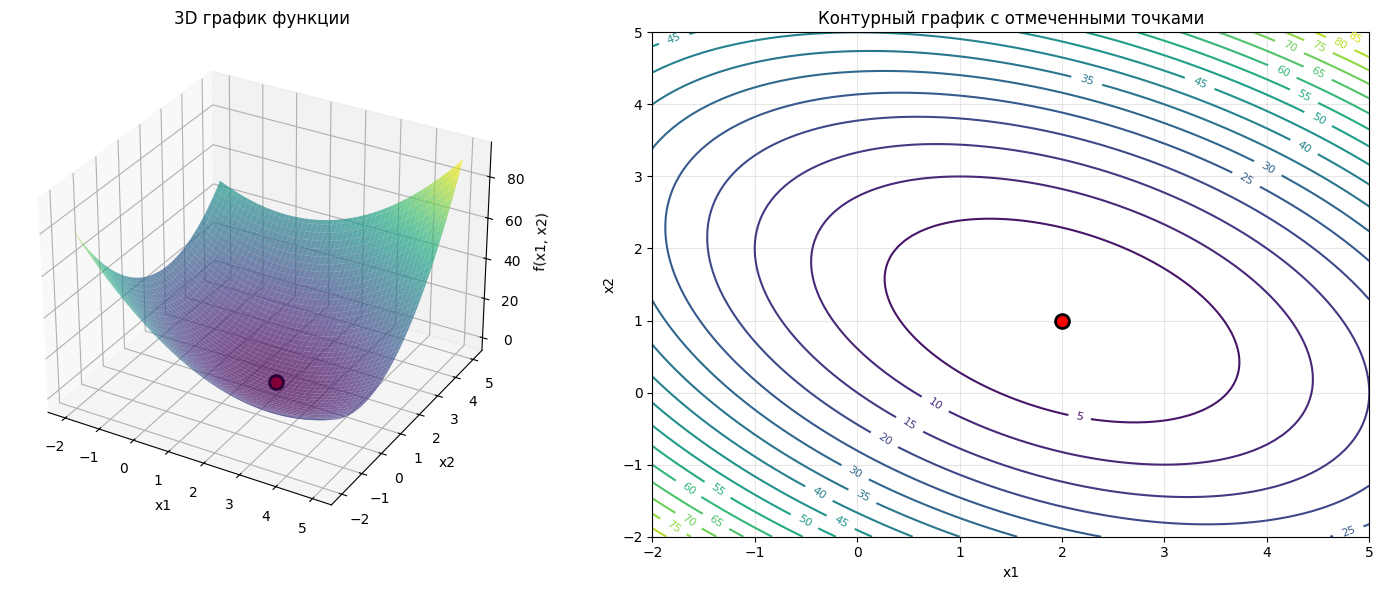


ТОЧНЫЙ АНАЛИТИЧЕСКИЙ РЕЗУЛЬТАТ:

Градиент функции: ∇f = (4*x1 + 2*x2 - 10, 2*x1 + 6*x2 - 10)

Матрица Гессе (гессиан):
⎡4  2⎤
⎢    ⎥
⎣2  6⎦

Собственные значения матрицы Гессе: {5 - sqrt(5): 1, sqrt(5) + 5: 1}
→ Матрица Гессе положительно определена, функция строго выпуклая
→ Найденная стационарная точка является ГЛОБАЛЬНЫМ минимумом


In [12]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Определяем символические переменные
x1, x2 = sp.symbols('x1 x2')

# Задаем функцию
f = 2*x1**2 + 2*x1*x2 + 3*x2**2 - 10*x1 - 10*x2 + 15

print("=" * 60)
print("ИССЛЕДОВАНИЕ ФУНКЦИИ НА ЭКСТРЕМУМЫ")
print("=" * 60)
print(f"\nФункция: f(x1, x2) = {f}")
print()

# 1. Находим частные производные первого порядка
f_x1 = sp.diff(f, x1)
f_x2 = sp.diff(f, x2)

print("1. ЧАСТНЫЕ ПРОИЗВОДНЫЕ ПЕРВОГО ПОРЯДКА:")
print(f"   ∂f/∂x1 = {f_x1}")
print(f"   ∂f/∂x2 = {f_x2}")
print()

# 2. Решаем систему уравнений для нахождения стационарных точек
print("2. СТАЦИОНАРНЫЕ ТОЧКИ:")
print("   Решаем систему:")
print(f"   {f_x1} = 0")
print(f"   {f_x2} = 0")
print()

# Решаем систему уравнений
solution = sp.solve([f_x1, f_x2], [x1, x2])

# Проверяем тип решения и извлекаем точки
if isinstance(solution, dict):
    # Если решение в виде словаря
    stationary_points = [(solution[x1], solution[x2])]
elif isinstance(solution, list):
    # Если решение в виде списка кортежей
    stationary_points = solution
else:
    stationary_points = [solution]

print("   Стационарные точки:")
for point in stationary_points:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        print(f"   x1 = {point[0]}, x2 = {point[1]}")
    else:
        print(f"   x1 = {point[0] if isinstance(point, (tuple, list)) else point}, x2 = {point[1] if isinstance(point, (tuple, list)) else '?'}")
print()

# 3. Находим вторые частные производные
f_xx = sp.diff(f_x1, x1)  # ∂²f/∂x1²
f_xy = sp.diff(f_x1, x2)  # ∂²f/∂x1∂x2
f_yy = sp.diff(f_x2, x2)  # ∂²f/∂x2²

print("3. ВТОРЫЕ ЧАСТНЫЕ ПРОИЗВОДНЫЕ:")
print(f"   A = ∂²f/∂x1² = {f_xx}")
print(f"   B = ∂²f/∂x1∂x2 = {f_xy}")
print(f"   C = ∂²f/∂x2² = {f_yy}")
print()

# 4. Исследуем каждую стационарную точку
print("4. ИССЛЕДОВАНИЕ ТИПА ЭКСТРЕМУМА:")
print("-" * 60)

# Преобразуем стационарные точки в список для единообразия
points_list = []
if isinstance(stationary_points, dict):
    points_list = [(stationary_points[x1], stationary_points[x2])]
elif isinstance(stationary_points, list):
    points_list = stationary_points
else:
    points_list = [(stationary_points, stationary_points)] if stationary_points else []

for i, point in enumerate(points_list, 1):
    # Извлекаем значения x1 и x2
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    # Вычисляем значения вторых производных в точке
    A_val = f_xx.subs({x1: x1_val, x2: x2_val})
    B_val = f_xy.subs({x1: x1_val, x2: x2_val})
    C_val = f_yy.subs({x1: x1_val, x2: x2_val})

    # Вычисляем дискриминант
    Delta = A_val * C_val - B_val**2

    # Вычисляем значение функции в точке
    f_val = f.subs({x1: x1_val, x2: x2_val})

    print(f"\nТочка {i}: ({x1_val}, {x2_val})")
    print(f"  Значение функции: f = {f_val}")
    print(f"  A = {A_val}, B = {B_val}, C = {C_val}")
    print(f"  Δ = AC - B² = {Delta}")

    # Определяем тип точки
    if Delta > 0:
        if A_val > 0:
            print(f"  → ТОЧКА МИНИМУМА (локальный минимум)")
        elif A_val < 0:
            print(f"  → ТОЧКА МАКСИМУМА (локальный максимум)")
    elif Delta < 0:
        print(f"  → СЕДЛОВАЯ ТОЧКА (не является экстремумом)")
    else:
        print(f"  → ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНОЕ ИССЛЕДОВАНИЕ (Δ = 0)")

print("\n" + "=" * 60)
print("ВЫВОД:")
print("=" * 60)

for i, point in enumerate(points_list, 1):
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    f_val = f.subs({x1: x1_val, x2: x2_val})

    A_val = f_xx.subs({x1: x1_val, x2: x2_val})
    B_val = f_xy.subs({x1: x1_val, x2: x2_val})
    C_val = f_yy.subs({x1: x1_val, x2: x2_val})
    Delta = A_val * C_val - B_val**2

    if Delta > 0 and A_val > 0:
        print(f"\n✓ В точке ({x1_val}, {x2_val}) функция имеет ЛОКАЛЬНЫЙ МИНИМУМ")
        print(f"  f_min = {f_val}")
    elif Delta > 0 > A_val:
        print(f"\n✓ В точке ({x1_val}, {x2_val}) функция имеет ЛОКАЛЬНЫЙ МАКСИМУМ")
        print(f"  f_max = {f_val}")
    elif Delta < 0:
        print(f"\n✗ В точке ({x1_val}, {x2_val}) седловая точка (экстремума нет)")

# Визуализация для наглядности
print("\n" + "=" * 60)
print("ВИЗУАЛИЗАЦИЯ:")
print("=" * 60)

# Создаем сетку для построения графиков
x1_vals = np.linspace(-2, 5, 100)
x2_vals = np.linspace(-2, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Преобразуем символьную функцию в числовую
f_numeric = sp.lambdify((x1, x2), f, 'numpy')
Z = f_numeric(X1, X2)

# Создаем фигуру с двумя подграфиками
fig = plt.figure(figsize=(15, 6))

# 3D поверхность
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.7, edgecolor='none')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('f(x1, x2)')
ax1.set_title('3D график функции')

# Отмечаем стационарные точки
for point in points_list:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    z_val = f_numeric(float(str(x1_val)), float(str(x2_val)))
    ax1.scatter(float(str(x1_val)), float(str(x2_val)), float(z_val),
               color='red', s=100, edgecolor='black', linewidth=2)

# Контурный график
ax2 = fig.add_subplot(122)
contour = ax2.contour(X1, X2, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_title('Контурный график с отмеченными точками')
ax2.grid(True, alpha=0.3)

# Отмечаем стационарные точки на контурном графике
for point in points_list:
    if isinstance(point, (tuple, list)) and len(point) == 2:
        x1_val, x2_val = point
    else:
        x1_val, x2_val = point, point

    ax2.scatter(float(str(x1_val)), float(str(x2_val)), color='red', s=100,
               edgecolor='black', linewidth=2, zorder=5)

plt.tight_layout()
plt.show()

# Дополнительный анализ: находим точное значение минимума
print("\n" + "=" * 60)
print("ТОЧНЫЙ АНАЛИТИЧЕСКИЙ РЕЗУЛЬТАТ:")
print("=" * 60)

# Находим градиент
gradient = [f_x1, f_x2]
print(f"\nГрадиент функции: ∇f = ({gradient[0]}, {gradient[1]})")

# Находим матрицу Гессе
hessian = sp.Matrix([[f_xx, f_xy], [f_xy, f_yy]])
print(f"\nМатрица Гессе (гессиан):")
sp.pprint(hessian)

# Определяем, является ли матрица положительно определенной
eigenvalues = hessian.eigenvals()
print(f"\nСобственные значения матрицы Гессе: {eigenvalues}")

if all(ev > 0 for ev in eigenvalues.keys()):
    print("→ Матрица Гессе положительно определена, функция строго выпуклая")
    print("→ Найденная стационарная точка является ГЛОБАЛЬНЫМ минимумом")
elif all(ev < 0 for ev in eigenvalues.keys()):
    print("→ Матрица Гессе отрицательно определена, функция строго вогнутая")
    print("→ Найденная стационарная точка является ГЛОБАЛЬНЫМ максимумом")